# Logging the logging in Germany over the last decades

The Bundesamt für Statistik (Federal Statistical Office of Germany) provides comprehensive data on logging activities in Germany over the last decades. This data includes information on the volume of timber harvested and the types of trees logged. Since the data is available from 1998 to 2025 multiple analyses can be performed.
For this work 5 research questions were formulated:
<mark>
1. How has the total volume of timber harvested in Germany changed over the last decades?
2. What are the reason behind the fluctuations in the volume of timber harvested in Germany?
3. What are the trends in logging activities for different types of woods in Germany?
4. What are the environmental impacts of logging activities in Germany?
5. What is the primary usage of the harvested timber in Germany?
</mark>

## Imports and Project Setup
In order to be able to rerun this notebook please execute the following steps:
```bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```
This will create a virtual environment and install all necessary dependencies. After that you can run the notebook and execute the following code cells to import the necessary libraries and set up the project structure.
The following code cell is used to import the `DataLoader` class which is used to process the CSV-data provided in `data/` aswell as other dependencies used for visualization.

In [94]:
import data_loader
import tools
import numpy as np
from matplotlib import pyplot as plt
import importlib
importlib.reload(data_loader)

dl = data_loader.DataLoader()

## RQ1: How has the total volume of timber harvested in Germany changed over the last decades?
To answer this question, the `wood_production.csv` file will be used. It contains data from the Destatis website on the volume of wood production in Germany. It not only contains the total volume but also the volumes of different types of wood. For this research question however only the total volume will be used.

### Processing the data
To process the data, the `DataLoader` class contains a method called `load_wood_production` which reads the CSV file and returns a DataFrame containing the relevant data. The following code cell demonstrates how to use this method. Also the data is filtered to only contain the time stamps from 1998 to 2025 and the actual value of the volume. This data will later be used for a visualization. 

In [95]:
overall_production = dl.load_overall_production("../data/wood_production.csv")
overall_production_sorted = overall_production[["time", "value"]].sort_values("time")

In addition to the concrete numerical values, a regression line is calculated to show the overall trend of the data.

In [96]:
slope, intercept = np.polyfit(overall_production_sorted["time"], overall_production_sorted["value"], 1)
x = np.linspace(overall_production_sorted["time"].min(), overall_production_sorted["time"].max(), 100)
y = slope * x + intercept

### Visualization
To visualize the data, the `matplotlib` library is used. The following code cell demonstrates how to create a line plot of the total volume of timber harvested over the years, along with the regression line to show the trend. The x-axis represents the years, while the y-axis represents the total volume of timber harvested in Germany.

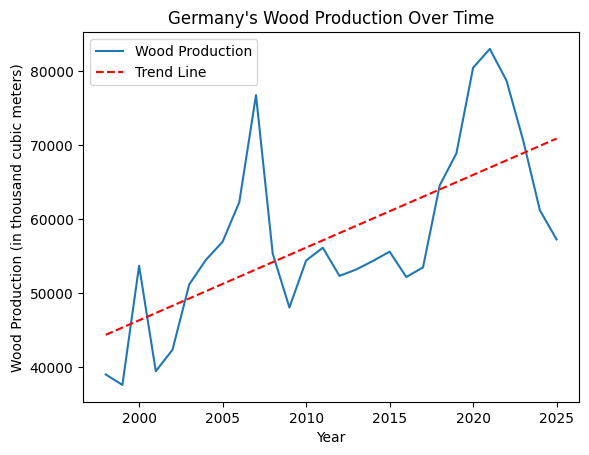

In [97]:
plt.plot(overall_production_sorted["time"].values, overall_production_sorted["value"].values, label="Wood Production")
plt.plot(x, y, color="red", linestyle="--", label=f"Trend Line")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Wood Production (in thousand cubic meters)")
plt.title("Germany's Wood Production Over Time")
plt.show()

### Analysis of the results and conclusion
As it can be seen in the plot, the volume of wood production in Germany is heavily increasing in trends of 1998 to 2025. This is especially observable in the regression line that shows a clear upward trend with a $\approx 1.5*x$ slope in a timespan of 27 years between 1998 and 2025. The actual trend line itself is not as linear and shows major fluctuations in the years 2000, 2004 to 2007 and 2017 to 2022. Since 2025 a downward trend can be observed. Finally, it can be concluded that the total volume of timber harvested in Germany has increased significantly over the last decades, with some fluctuations in between. What the reasons for these fluctuations are and how they can be explained will be analyzed in the next research questions.

## RQ2: What are the reason behind the fluctuations in the volume of timber harvested in Germany?
In order to fully understand the background of said fluctuations, more data is needed. For this purpose, literature research was conducted to find out what were the main driving factors behind the observed phenomenon. 

### Literature research
Many factors can influence the volume of timber harvested in a country. However, the most important ones are not the economic factors but rather the environmental ones. The spikes in overall volume observed in RQ1 can be almost perfectly explained by the occurrence of natural disasters such as storms, droughts and insect infestations. For the 2000 spike, the storm "Lothar" is beeing identified as the main driver. [[1]](https://www.holzkurier.com/rundholz/2023/07/holzeinschlag-deutschland-1998-2022.html)[[2]](https://de.wikipedia.org/wiki/Orkan_Lothar)

### Visualization of the results
To visualize the results of the literature research, the same plot but without the regression line from RQ1 is used with the addition of annotations that indicate the exact dates of the natural disasters.


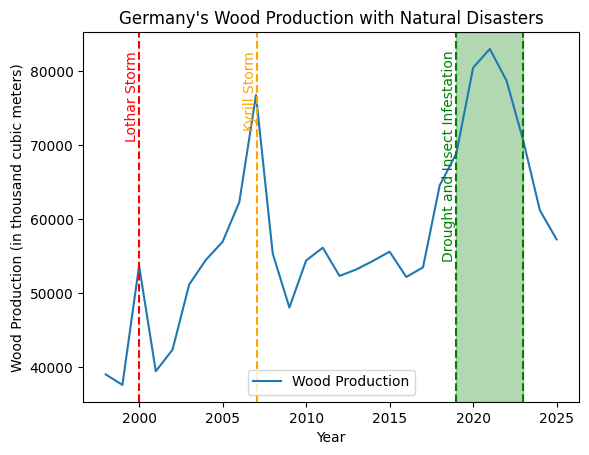

In [98]:
plt.plot(overall_production_sorted["time"].values, overall_production_sorted["value"].values, label="Wood Production")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Wood Production (in thousand cubic meters)")
plt.title("Germany's Wood Production with Natural Disasters")

ax = plt.gca()
ax.axvline(tools.date_to_numerical_year("25-12-1999"), color='red', linestyle='--')
ax.text(tools.date_to_numerical_year("25-12-1999"), 0.95, "Lothar Storm", transform=ax.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='red')

bx = plt.gca()
bx.axvline(tools.date_to_numerical_year("18-01-2007"), color='orange', linestyle='--')
bx.text(tools.date_to_numerical_year("18-01-2007"), 0.95, "Kyrill Storm", transform=bx.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='orange')

cx = plt.gca()
cx.axvspan(tools.date_to_numerical_year("01-01-2019"), tools.date_to_numerical_year("31-12-2022"), color='green', alpha=0.3)
cx.axvline(tools.date_to_numerical_year("01-01-2019"), color='green', linestyle='--')
cx.axvline(tools.date_to_numerical_year("31-12-2022"), color='green', linestyle='--')
cx.text(tools.date_to_numerical_year("01-01-2019"), 0.95, "Drought and Insect Infestation", transform=cx.get_xaxis_transform(),
        rotation=90, va='top', ha='right', color='green')

plt.show()


### Analysis of the results and conclusion
As it can be seen in the plot, "Germany's Wood Production with Natural Disasters", the spikes in wood production can be almost perfectly explained by the occurrence of natural disasters. The storm "Lothar" in 1999 caused a significant increase in wood production due to the large number of trees that were damaged and needed to be harvested. Similarly, the storm "Kyrill" in 2007 also led to a spike in wood production for the same reasons. The period from 2019 to 2022, which is marked as "Drought and Insect Infestation", also shows a significant increase in wood production, likely due to the increased need for harvesting trees that were affected by drought and insect infestations. Overall, it can be concluded that natural disasters have a significant impact on the volume of timber harvested in Germany, leading to fluctuations in wood production over the years and even make up a substantial part of the overall wood production. Wether that additional wood was utilized will be analyzed in RQ5.